- Labels
- Each training and test example is assigned to one of the following labels:
- 
- 0 T-shirt/top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandal
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boot

[ dia 분류 ]
- 다중분류
- 지도학습 - 분류
- 이진분류

In [113]:
## 모듈로딩
import pandas as pd  # 데이터 모듈
import numpy as np

import torch         
# tensor 및 기본 함수 모듈   
import torch.nn as nn
# 인공신경망 관련 모듈
import torch.nn.functional as F
# 인공신경망 관련 함수
import torch.optim as optim
# 최적화 모듈

from sklearn.model_selection import train_test_split
# 학습용 데이터셋 관련 함수

from torchmetrics.classification import *
from torch.utils.data import Dataset, DataLoader

In [114]:
dataDF = pd.DataFrame(pd.read_csv('../_data/diamonds.csv', engine='python'))
diaDF = dataDF.copy()

In [115]:
diaDF.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [116]:
diaDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [117]:
diaDF['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [118]:
sorted(diaDF['color'].unique())

['D', 'E', 'F', 'G', 'H', 'I', 'J']

In [119]:
diaDF['clarity'].value_counts()

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

In [120]:
diaDF['clarity'] =diaDF['clarity'].replace({'I1':0, 'SI2':1, 'SI1':2, 'VS2':3, 'VS1':4, 'VVS2':5, 'VVS1':6, 'IF':7 })
diaDF['color'] = diaDF['color'].replace({'D':0, 'E':1, 'F':2, 'G':3, 'H':4, 'I':5, 'J':6})
diaDF['cut'] = diaDF['cut'].replace({'Fair':0, 'Good':1, 'Very Good':2, 'Good':3, 'Premium':4, 'Ideal':5})

C:\Users\kdt\AppData\Local\Temp\ipykernel_14184\1144324279.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diaDF['clarity'] =diaDF['clarity'].replace({'I1':0, 'SI2':1, 'SI1':2, 'VS2':3, 'VS1':4, 'VVS2':5, 'VVS1':6, 'IF':7 })
C:\Users\kdt\AppData\Local\Temp\ipykernel_14184\1144324279.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diaDF['color'] = diaDF['color'].replace({'D':0, 'E':1, 'F':2, 'G':3, 'H':4, 'I':5, 'J':6})
C:\Users\kdt\AppData\Local\Temp\ipykernel_14184\1144324279.py:3: FutureWarning: Downcasting behavior in `

In [123]:
from sklearn.preprocessing import StandardScaler
sacler = StandardScaler()
diaDF['depth'] = sacler.fit_transform(diaDF['depth'].values.reshape(-1, 1))
sacler = StandardScaler()
diaDF['table'] = sacler.fit_transform(diaDF['table'].values.reshape(-1, 1))

In [124]:
diaDF.clarity.unique()

array([1, 2, 4, 3, 5, 6, 0, 7])

In [125]:
featureDF = diaDF.loc[:, diaDF.columns[diaDF.columns != 'clarity']]
targetDF = diaDF.loc[:,'clarity']

In [126]:
## 학습용, 테스트용 데이터셋 분리 
X_train, X_test, y_train, y_test = train_test_split(featureDF, 
                                                    targetDF, 
                                                    test_size=0.2,
                                                    stratify=targetDF,
                                                    random_state=42)

print(f'[X_train] {X_train.shape}, {X_train.ndim}D  [y_train] {y_train.shape}, {y_train.ndim}D')
print(f'[X_test]  {X_test.shape}, {X_test.ndim}D  [y_test] {y_test.shape}, {y_test.ndim}D')


[X_train] (43152, 9), 2D  [y_train] (43152,), 1D
[X_test]  (10788, 9), 2D  [y_test] (10788,), 1D


In [164]:
## 데이터셋 클래스 생성

class DiaDataSet(Dataset):
    #피쳐와 타겟 분리 및 전처리 진행
    def __init__(self, featureDF, targetDF):
        super().__init__()
        self.feature = featureDF
        self.target = targetDF
        self.rows = featureDF.shape[0]
        self.cols = featureDF.shape[1]
        
    # 데이터셋의 샘플 수 반환 메서드
    def __len__(self):
        return self.rows
        
    # DataLoader 에서 batch_size만큼 호출하는 메서드
    # 인덱스에 해당하는 피쳐와 타겟 반환, 단 Tensor 형태
    def __getitem__(self, index):
        arrFeature = self.feature.iloc[index].values
        arrTarget = self.target.iloc[index].reshape(-1,1)  
        
        return torch.FloatTensor(arrFeature), torch.FloatTensor(arrTarget)

In [165]:
dataset = DiaDataSet(X_train, y_train)

In [166]:
dataset.feature.shape, dataset.target.shape

((43152, 9), (43152,))

In [167]:
## DataLoader 연동
loader = DataLoader(dataset, batch_size=1)
for feature, target in loader:
    print(feature, target)
    break


tensor([[3.0000e-01, 4.0000e+00, 1.0000e+00, 1.0512e-01, 1.5855e+00, 8.4400e+02,
         4.3200e+00, 4.2800e+00, 2.6600e+00]]) tensor([[[3.]]])


In [168]:
trainDS = DiaDataSet(X_train, y_train)
testDS  = DiaDataSet(X_test, y_test)

In [169]:

class Price_Model(nn.Module):
    # 인스턴스 초기화 및 생성 메서드
    def __init__(self):
        super().__init__() #부모(nn.Module)의 init 생성
        print('__init__()')
        self.layers = nn.Sequential(
                        nn.Linear(9, 360),
                        nn.ReLU(),
                        nn.Linear(360, 200),
                        nn.ReLU(),
                        nn.Linear(200, 100),
                        nn.ReLU(),
                        nn.Linear(100, 50),
                        nn.ReLU(),
                        nn.Linear(50, 8)
        )

    # 순전파 학습 메서드 
    def forward(self, data):
        return self.layers(data)
               

In [170]:
model = Price_Model()
for feature, target  in testDS:
    pre_ = model(feature)
    print(pre_, target)
    print(pre_.max(), pre_.argmax())
    break

__init__()
tensor([-26.3772,  24.7644,  25.3958,  23.0477,  40.9139,   0.3784,  20.5828,
          7.2348], grad_fn=<ViewBackward0>) tensor([[4.]])
tensor(40.9139, grad_fn=<MaxBackward1>) tensor(4)


In [171]:
X_train.shape

(43152, 9)

In [184]:
## [5-1] 학습 관련 설정들
EPOCHS = 30                                         # 학습용 DS를 처음부터 끝까지 1번 학습하는 것을 에포크
BATCH_SIZE = 43512//2                                    # DS를 학습량 만큼 나눈 사이즈
ITERATION = int(X_train.shape[0]/BATCH_SIZE)         # 학습용 DS이 분리된 수 => 1에포크에 W, b 업데이트 횟수
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"DEVICE : {DEVICE}, EPOCHS : {EPOCHS}, BATCH_SIZE : {BATCH_SIZE} ITERATION: {ITERATION}")
      

DEVICE : cpu, EPOCHS : 30, BATCH_SIZE : 21756 ITERATION: 1


In [185]:
# [5-2] 학습 관련 인스턴스들
TRAINDL   = DataLoader(trainDS, batch_size=BATCH_SIZE)  #학습용
TESTDL    = DataLoader(testDS,  batch_size=BATCH_SIZE)  #테스트용
LR      = 0.0001                                # Learning Rate
MODEL  = Price_Model()                           #학습 모델
OPTIMIZER = optim.Adam(MODEL.parameters(), lr=LR)      #최적화 즉, 경사하강법 알고리즘으로 W, b의 값 개신
LOSS_FN = nn.MSELoss()


__init__()


In [186]:
##- 학습 함수 --------------------------------------------
##- 학습용 데이터셋으로 모델 검증
##- -----------------------------------------------------
def training():
    # 학습 모드 설정
    model.train()

    E_LOSS = 0
    E_ACC = 0
    #for i in range(ITERATION): 
    for feature, target in TRAINDL:
        # 배치 크기만큼 feature, target 로딩
        # print(feature.shape, target.shape)
                                                                            
        # 가중치 기울기 0 초기화
        OPTIMIZER.zero_grad()

        # 학습 진행
        pre_y = MODEL(feature)

        # 손실 계산
        loss = LOSS_FN(pre_y, target.reshape(-1,1))
        
        # 역전파 진행
        loss.backward()

        # 가중치/절편 업데이트
        OPTIMIZER.step()
        
        # 정확도 계산
        accuracy = MulticlassAccuracy(num_classes=8)
        acc = accuracy(pre_y, target.reshape(-1))
       
        E_ACC += acc.item()
        E_LOSS += loss.item()

    return E_LOSS/ITERATION, E_ACC/ITERATION

In [190]:
# 학습함수
def evaluate():
    # 에포크 단위로 검증 => 검증 모드
    MODEL.eval()
    
    # W, b가 업데이트 해제
    with torch.no_grad():
        # 방법1) 테스트용 DL 적용
        T_LOSS, T_ACC, T_PRE, T_RECALL, CNT = 0, 0, 0, 0, 0
        for feature, target in TESTDL:            
            # 검증진행
            pre_y= MODEL(feature)
            
            # 손실 계산
            loss = LOSS_FN(pre_y, target.reshape(-1,1))
            
            # 정확도 계산
            accuracy = MulticlassAccuracy(num_classes=8)
            prescision = MulticlassPrecision(num_classes=8)
            recall = MulticlassRecall(num_classes=8)
            f1 = MulticlassF1Score(num_classes=8)
            
            
            T_PRE += prescision(pre_y, target.reshape(-1)).item()
            T_RECALL += recall(pre_y, target.reshape(-1)).item()
            T_ACC += accuracy(pre_y, target.reshape(-1)).item()
            T_LOSS += loss.item()
            CNT += 1
            return T_LOSS/CNT, T_ACC/CNT#, T_PRE/CNT, T_RECALL/CNT
    
        # 방법2) 전테 테스트데이터
        # DF/SR => Tensor화
        # 검증용 데이터셋 => 텐서화 ndarray ==> tensor변환
        x = torch.FloatTensor(X_test.values) 
        y = torch.FloatTensor(y_test.values)
        
        # 검증진행
        pre_y= MODEL(x)
        
        # 손실 계산
        loss = LOSS_FN(pre_y, y.reshape(-1).long())

        # 정확도 계산
        accuracy = MulticlassAccuracy(num_classes=3)
        acc = accuracy(pre_y, y.reshape(-1))
        
        return loss.item(), acc.item()

In [191]:
# 방법 2: time 모듈 사용
import time

# 현재 시간을 초 단위로 출력
print(time.time())

# 포맷팅된 시간 출력
print(time.strftime("%H:%M:%S"))

1743417634.7070954
19:40:34


In [192]:
HIST ={'Train':[], 'Valid':[]}   
# 에포크 단위 학습/검증 진행 
for epoch in range(EPOCHS):
    a = time.time()
    trainLoss, trainAcc = training()
    validLoss, validAcc = evaluate()

    HIST['Train'].append((trainLoss, trainAcc))
    HIST['Valid'].append((validLoss, validAcc))

    print(f'\nEPOCH[{epoch}/{EPOCHS}]----------------')
    print(f'- TRAIN_LOSS {trainLoss:.5f}    ACC {trainAcc:.5f}')
    print(f'- VALID_LOSS {validLoss:.5f}    ACC {validAcc:.5f}')
    
    print(time.time()-a)
print(time.strftime("%H:%M:%S"))

c:\Users\kdt\anaconda3\envs\DL_TORCH\lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([10788, 1])) that is different to the input size (torch.Size([10788, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



EPOCH[0/30]----------------
- TRAIN_LOSS 1100.61255    ACC 0.25000
- VALID_LOSS 275.81268    ACC 0.12500
3.955460548400879

EPOCH[1/30]----------------
- TRAIN_LOSS 470.09354    ACC 0.25000
- VALID_LOSS 137.47005    ACC 0.12500
4.267224311828613

EPOCH[2/30]----------------
- TRAIN_LOSS 236.21056    ACC 0.25000
- VALID_LOSS 65.76550    ACC 0.12500
3.900089740753174

EPOCH[3/30]----------------
- TRAIN_LOSS 111.17529    ACC 0.25000
- VALID_LOSS 31.82404    ACC 0.12500
4.11953067779541

EPOCH[4/30]----------------
- TRAIN_LOSS 58.40813    ACC 0.25000
- VALID_LOSS 25.46949    ACC 0.12500
3.9129750728607178

EPOCH[5/30]----------------
- TRAIN_LOSS 52.44580    ACC 0.25000
- VALID_LOSS 29.05651    ACC 0.12500
3.9681620597839355

EPOCH[6/30]----------------
- TRAIN_LOSS 61.13933    ACC 0.25000
- VALID_LOSS 34.19090    ACC 0.12500
3.980560302734375

EPOCH[7/30]----------------
- TRAIN_LOSS 70.26712    ACC 0.25000
- VALID_LOSS 34.90679    ACC 0.12500
4.082954168319702

EPOCH[8/30]------------

In [193]:
# MODEL.eval()
xdata = range(10)
ydata1Loss = []
ydata1Acc = []
for loss, acc in HIST['Train']:
    ydata1Loss.append(loss)
    ydata1Acc.append(acc)
ydata2Loss = []
ydata2Acc = []
for loss, acc in HIST['Valid']:
    ydata2Loss.append(loss)
    ydata2Acc.append(acc)




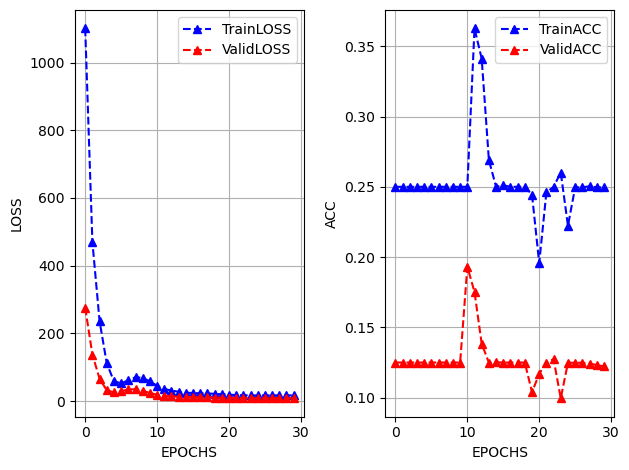

In [194]:
## 모델 성능 시각화 
import matplotlib.pyplot as plt

# plt.plot(HIST['Train'][0], 'b^--', label='TrainLOSS')
# plt.plot(HIST['Valid'][0], 'r^--', label='ValidLOSS')
# plt.plot(HIST['Train'][1], 'bo--', label='TrainACC')
# plt.plot(HIST['Valid'][1], 'ro--', label='ValidACC')

fig, ax = plt.subplots(1,2)
ax = ax.flatten()
ax[0].plot(ydata1Loss, 'b^--', label='TrainLOSS')
ax[1].plot(ydata1Acc, 'b^--', label='TrainACC')

ax[0].plot(ydata2Loss, 'r^--', label='ValidLOSS')
ax[1].plot(ydata2Acc, 'r^--', label='ValidACC')


ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('EPOCHS')
ax[1].set_xlabel('EPOCHS')

ax[0].set_ylabel('LOSS')
ax[1].set_ylabel('ACC')
plt.tight_layout()
plt.show()